In [ ]:
!pip install diffusers transformers torch accelerate pillow


In [ ]:
import torch
from diffusers import StableDiffusionPipeline
import os


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")  # use GPU


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


In [ ]:
output_dir = "synthetic_dataset"
os.makedirs(output_dir, exist_ok=True)


In [ ]:
prompts = [
    "A cute puppy playing in the park with yellow ball and ",
    "A futuristic city at night with flying cars",
    "A robot studying in a classroom with math copy with question of Quantization problem ",
    "A beautiful mountain landscape with river",
    "A doctor using advanced medical technology"
]


In [ ]:
for i, prompt in enumerate(prompts):
    image = pipe(prompt).images[0]
    image_path = os.path.join(output_dir, f"image_{i+1}.png")
    image.save(image_path)
    print(f"Saved: {image_path}")


  0%|          | 0/50 [00:00<?, ?it/s]

Saved: synthetic_dataset/image_1.png


  0%|          | 0/50 [00:00<?, ?it/s]

Saved: synthetic_dataset/image_2.png


  0%|          | 0/50 [00:00<?, ?it/s]

Saved: synthetic_dataset/image_3.png


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

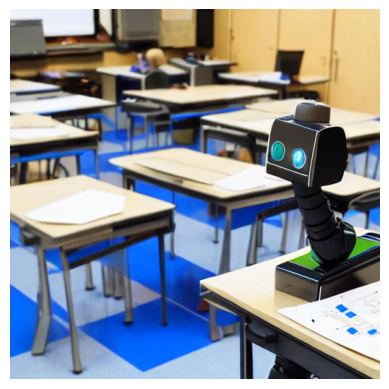

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("synthetic_dataset/image_2.png")
plt.imshow(img)
plt.axis("off")
